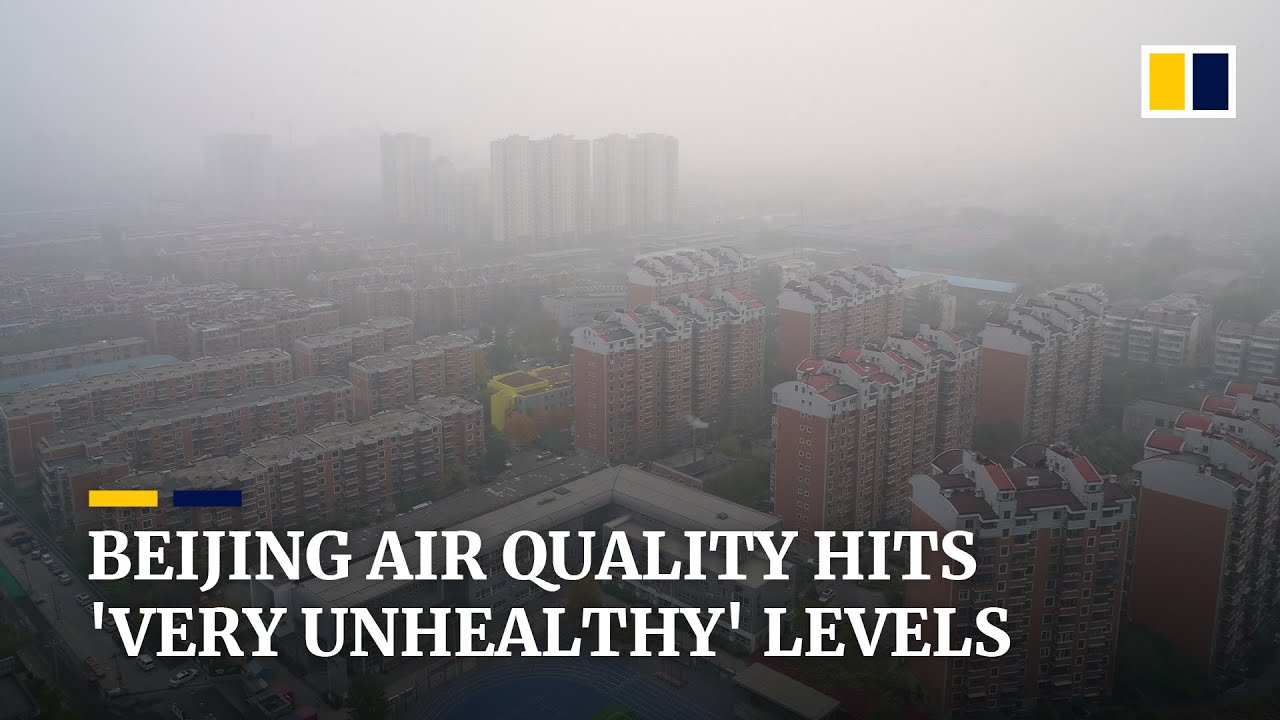

## Содержание

#### О датасете
#### Анализ (EDA)
#### Предобработка данных
#### Базовая модель 
#### Multi-Step Forecasting (24-Hour Prediction)
#### Single-Layer LSTM
#### Two-Layer LSTM
#### LSTM + Decoder Seq2Seq
#### Заключение

## Это знаменитый Beijing PM2.5 Dataset от института Tsinghua University + U.S. Embassy air-quality monitoring в формате, подготовленном для задач машинного обучения. Это один из самых популярных датасетов в мире для анализа загрязнения воздуха и для моделей RNN/LSTM.

### Он содержит данные:

концентрацию мелкодисперсной пыли PM2.5 в Пекине

почасовые метеорологические параметры

период наблюдений: январь 2010 - декабрь 2014

Это реальные наблюдения

### Размер и период данных

43824 строк

данные идут строго с разницей в 1 час

нет разрывов по времени (что редкость!)

### Период:

2010-01-01 00:00 → 2014-12-31 23:00

### Всего: почти 5 лет непрерывных измерений.

## В датасете есть 13 колонок:

No - порядковый номер строки

year, month, day, hour	                       -  компоненты времени

pm2.5	                                       - концентрация PM2.5 (μg/m³) - **таргет**

DEWP	                                       - dew point-точка росы

TEMP	                                       -  температура

PRES	                                      -  атмосферное давление

cbwd	                                       - направление ветра

Iws	                                           - скорость ветра

Is	                                           - снеговые осадки

Ir	                                           - дождевые осадки

## Главная цель датасета

Создан для изучения:

-- как меняется качество воздуха во времени,

-- какие факторы влияют на загрязнение,

-- как прогнозировать pollution модели типа:

time-series regression

-- RNN, LSTM, GRU

-- многошаговый прогноз

-- anomaly/peak detection

## EDA

In [70]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.layers import Dense, LSTM, Input
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

In [71]:
df = pd.read_csv('/mnt/c/KV_AI_JLR_12/pollution.csv')

In [72]:
df.shape

(43824, 13)

In [73]:
df.columns.tolist()

['No',
 'year',
 'month',
 'day',
 'hour',
 'pm2.5',
 'DEWP',
 'TEMP',
 'PRES',
 'cbwd',
 'Iws',
 'Is',
 'Ir']

In [74]:
df.head(30)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0
5,6,2010,1,1,5,NaN,-19,-10.0,1017.0,NW,16.10,0,0
6,7,2010,1,1,6,NaN,-19,-9.0,1017.0,NW,19.23,0,0
7,8,2010,1,1,7,NaN,-19,-9.0,1017.0,NW,21.02,0,0
8,9,2010,1,1,8,NaN,-19,-9.0,1017.0,NW,24.15,0,0
9,10,2010,1,1,9,NaN,-20,-8.0,1017.0,NW,27.28,0,0


In [75]:
df.describe()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,12651.043435,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,1.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,21912.500000,2012.000000,7.000000,16.000000,11.500000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,32868.250000,2013.000000,10.000000,23.000000,17.250000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [76]:
df.isnull().sum()

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [77]:
df.index = pd.to_datetime(df[['year', 'month','day','hour']], format='%Y-%m-%d %H')
df = df.drop(columns=['No', 'year', 'month','day','hour'])
df = df.rename(columns={
    'pm2.5': 'pollution',
    'DEWP': 'dew_point',
    'TEMP': 'temperature',
    'cbwd': 'wind_direction',
    'Iws': 'wind_speed',
    'PRES': 'pressure',
    'Is': 'snow',
    'Ir': 'rain'

})
df = df[24:]
df.head(10)

,pollution,dew_point,temperature,pressure,wind_direction,wind_speed,snow,rain
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0
2010-01-02 05:00:00,109.0,-7,-6.0,1022.0,SE,7.14,3,0
2010-01-02 06:00:00,105.0,-7,-6.0,1023.0,SE,8.93,4,0
2010-01-02 07:00:00,124.0,-7,-5.0,1024.0,SE,10.72,0,0
2010-01-02 08:00:00,120.0,-8,-6.0,1024.0,SE,12.51,0,0
2010-01-02 09:00:00,132.0,-7,-5.0,1025.0,SE,14.30,0,0


In [78]:
df.describe()

,pollution,dew_point,temperature,pressure,wind_speed,snow,rain
count,41757.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,98.613215,1.828516,12.459041,1016.447306,23.894307,0.052763,0.195023
std,92.050387,14.429326,12.193384,10.271411,50.022729,0.760582,1.416247
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [79]:
df["pollution"].isna().mean()

0.04664383561643835

In [80]:
df.isna().mean().sort_values(ascending=False)

pollution         0.046644
dew_point         0.000000
temperature       0.000000
pressure          0.000000
wind_direction    0.000000
wind_speed        0.000000
snow              0.000000
rain              0.000000
dtype: float64

In [81]:
df["pollution"].isna().groupby(df.index.year).mean() * 100

2010    7.383242
2011    8.310502
2012    5.566940
2013    0.936073
2014    1.130137
Name: pollution, dtype: float64

In [82]:
df["pollution"].isna().groupby(df.index.month).mean() * 100

1      6.087662
2      0.325059
3      4.408602
4      5.416667
5      2.983871
6      5.416667
7      1.962366
8     10.295699
9      7.416667
10     3.790323
11     2.750000
12     4.811828
Name: pollution, dtype: float64

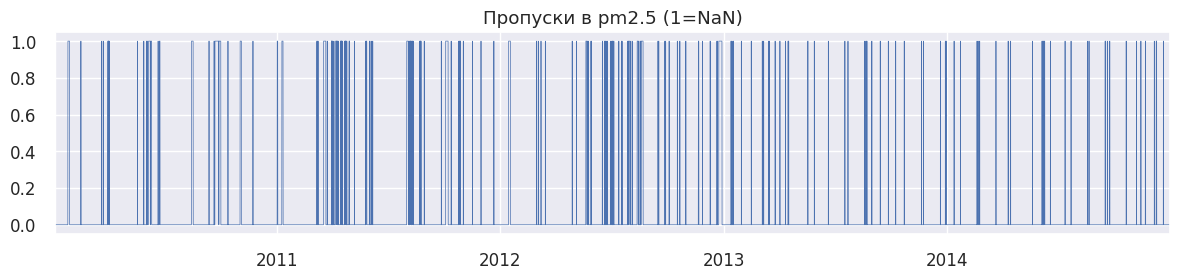

In [83]:
plt.figure(figsize=(12, 3))
df["pollution"].isna().astype(int).plot(linewidth=0.5)
plt.title("Пропуски в pm2.5 (1=NaN)")
plt.tight_layout()
plt.show()

In [84]:
pm = df['pollution']

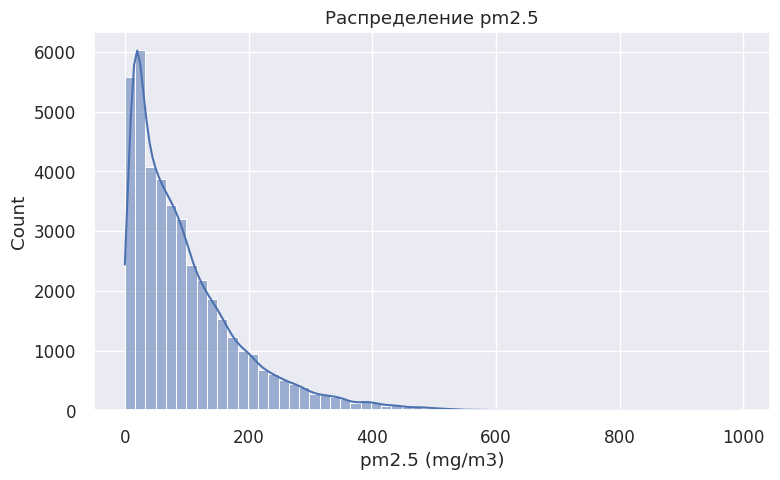

In [85]:
plt.figure(figsize=(8, 5))
sns.histplot(pm, bins=60, kde=True)
plt.title("Распределение pm2.5")
plt.xlabel("pm2.5 (mg/m3)")
plt.tight_layout()
plt.show()

Средний pm2.5 по годам:
2010    104.045730
2011     99.071340
2012     90.545871
2013    101.712376
2014     97.734557
Name: pollution, dtype: float64


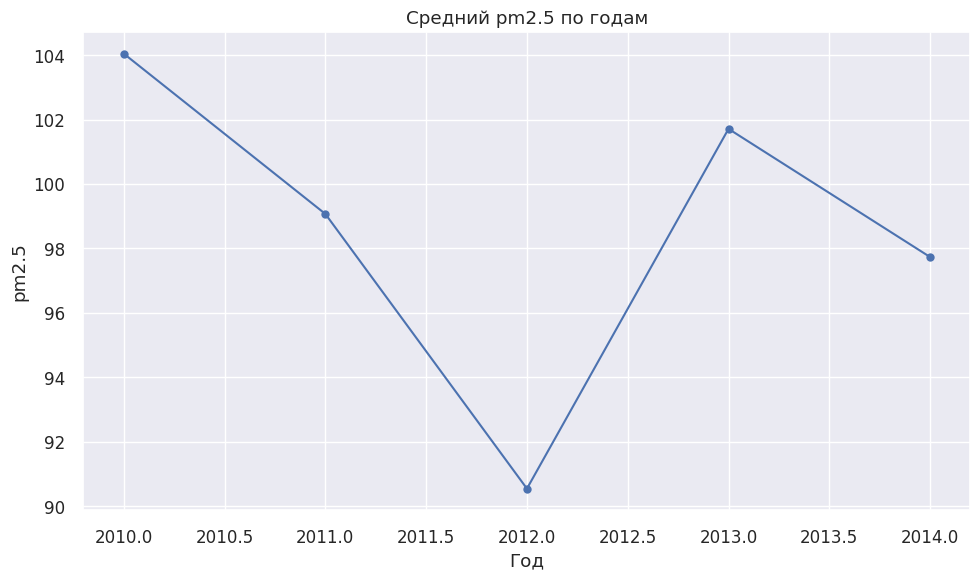

Средний pm2.5 по месяцам:
1     115.059061
2     125.736140
3      97.757593
4      83.709251
5      80.113051
6      96.513656
7      94.332328
8      79.996704
9      85.209421
10    120.401509
11    105.762639
12     98.200226
Name: pollution, dtype: float64


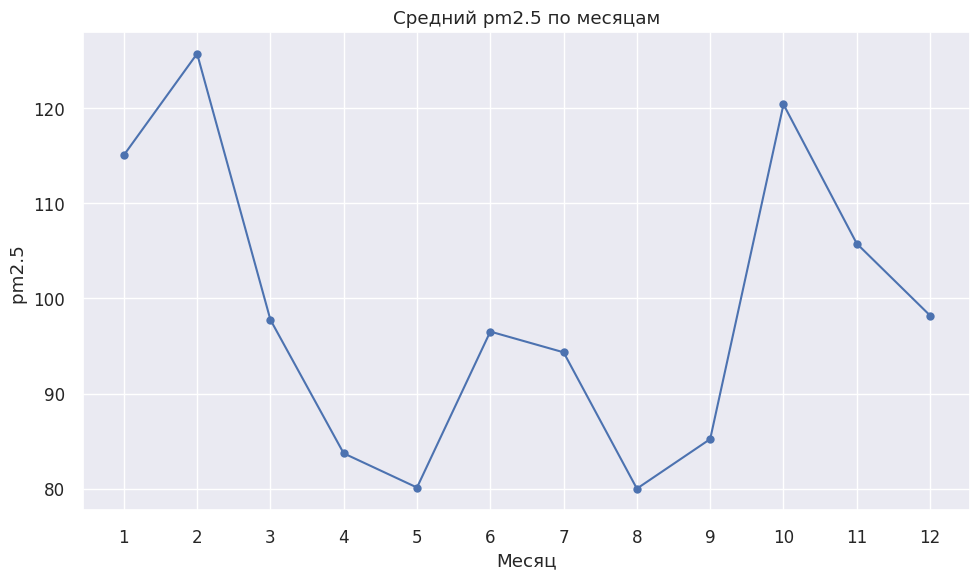

In [86]:
# Средний pm2.5 по годам
pm_year = pm.groupby(df.index.year).mean()
print("Средний pm2.5 по годам:")
print(pm_year)

plt.figure(figsize=(10, 6))
pm_year.plot(marker="o")
plt.title("Средний pm2.5 по годам")
plt.ylabel("pm2.5")
plt.xlabel("Год")
plt.tight_layout()
plt.show()

# Средний pm2.5 по месяцам (усреднённый по всем годам)
pm_month = pm.groupby(df.index.month).mean()
print("Средний pm2.5 по месяцам:")
print(pm_month)

plt.figure(figsize=(10, 6))
pm_month.plot(marker="o")
plt.title("Средний pm2.5 по месяцам")
plt.xlabel("Месяц")
plt.ylabel("pm2.5 ")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Средний pm2.5 по часу суток:
0     113.390202
1     113.698567
2     110.323174
3     108.042980
4     104.080275
5     100.013218
6      96.882759
7      96.024727
8      95.907940
9      94.672800
10     93.447520
11     91.678633
12     89.448873
13     87.990280
14     86.283247
15     85.534215
16     85.922280
17     87.571183
18     91.507710
19     97.398393
20    104.614368
21    109.249856
22    111.021252
23    111.889782
Name: pollution, dtype: float64


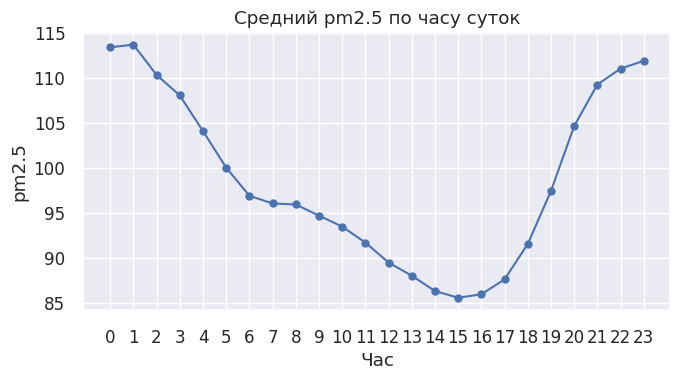

In [87]:
# Суточная сезонность (по часам)
pm_hour = pm.groupby(df.index.hour).mean()
print("Средний pm2.5 по часу суток:")
print(pm_hour)

plt.figure(figsize=(7, 4))
pm_hour.plot(marker="o")
plt.title("Средний pm2.5 по часу суток")
plt.xlabel("Час")
plt.ylabel("pm2.5")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

Распределение направлений ветра:
wind_direction
SE    15290
NW    14130
cv     9384
NE     4996
Name: count, dtype: int64
Средний pm2.5 по направлениям ветра:
wind_direction
NW     70.127633
NE     90.177670
SE    110.821588
cv    126.151945
Name: pollution, dtype: float64


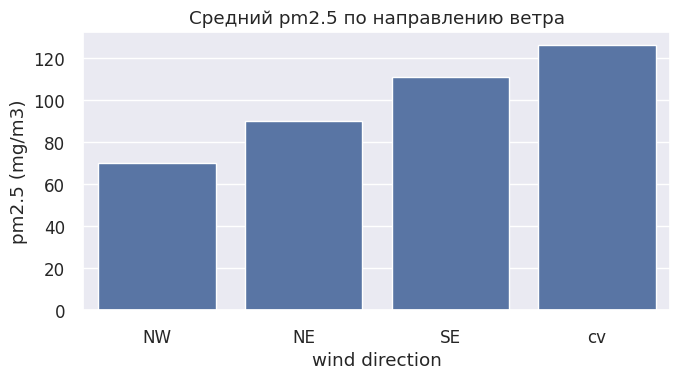

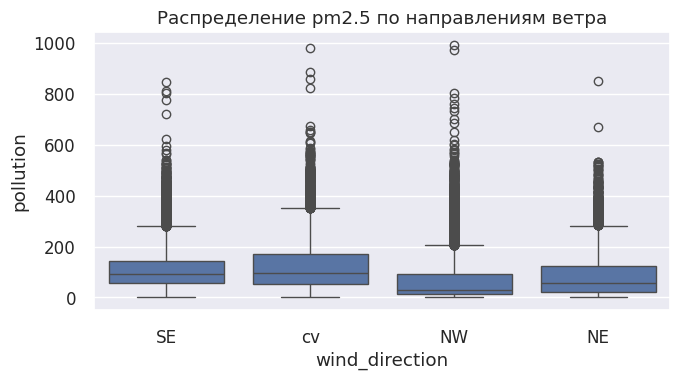

In [88]:
# Ветер: распределение и влияние на pm2.5

if "wind_direction" in df.columns:
    print("Распределение направлений ветра:")
    print(df["wind_direction"].value_counts())

    pm_by_cbwd = df.groupby("wind_direction")["pollution"].mean().sort_values()
    print("Средний pm2.5 по направлениям ветра:")
    print(pm_by_cbwd)

    plt.figure(figsize=(7, 4))
    sns.barplot(x=pm_by_cbwd.index, y=pm_by_cbwd.values)
    plt.title("Средний pm2.5 по направлению ветра")
    plt.xlabel("wind direction")
    plt.ylabel("pm2.5 (mg/m3)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="wind_direction", y="pollution")
    plt.title("Распределение pm2.5 по направлениям ветра")
    plt.tight_layout()
    plt.show()

Корреляционная матрица
pollution      1.000000
dew_point      0.171423
snow           0.019266
pressure      -0.047282
rain          -0.051369
temperature   -0.090534
wind_speed    -0.247784
Name: pollution, dtype: float64


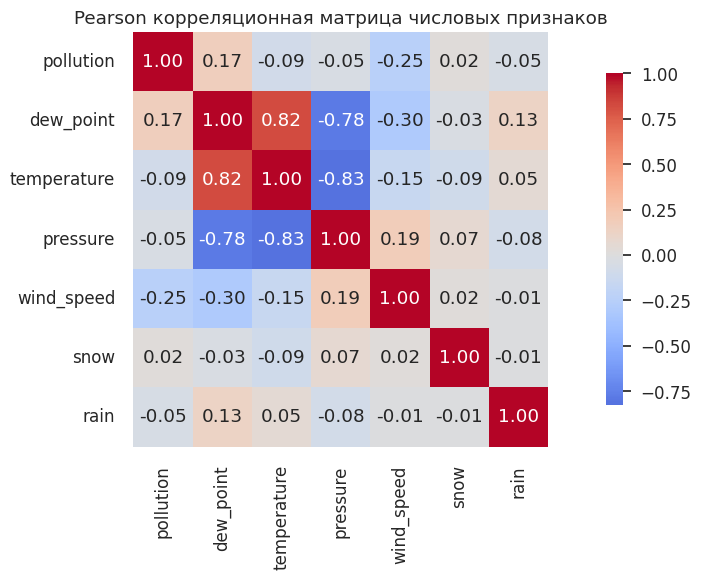

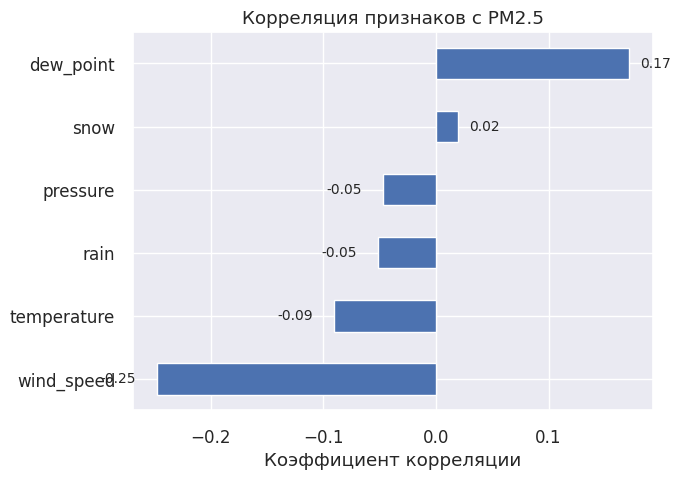

In [89]:
# Корреляции между признаками
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

print("Корреляционная матрица")
print(corr["pollution"].sort_values(ascending=False))

plt.figure(figsize=(12, 6))
sns.heatmap(
    corr,
    annot=True,       
    fmt=".2f",        
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson корреляционная матрица числовых признаков")
plt.tight_layout()
plt.show()
plt.figure(figsize=(7, 5))


corr_pm = corr["pollution"].drop("pollution").sort_values()
ax = corr_pm.plot(kind="barh")
for i, v in enumerate(corr_pm.values):
    ax.text(
        v + 0.01 if v >= 0 else v - 0.05,
        i,
        f"{v:.2f}",
        va="center",
        fontsize=10
    )

plt.title("Корреляция признаков с PM2.5")
plt.xlabel("Коэффициент корреляции")
plt.tight_layout()
plt.show()

Spearman: корреляции с PM2.5 (pollution)
pollution      1.000000
dew_point      0.299706
snow           0.046978
temperature    0.010784
rain          -0.002359
pressure      -0.141668
wind_speed    -0.360019
Name: pollution, dtype: float64


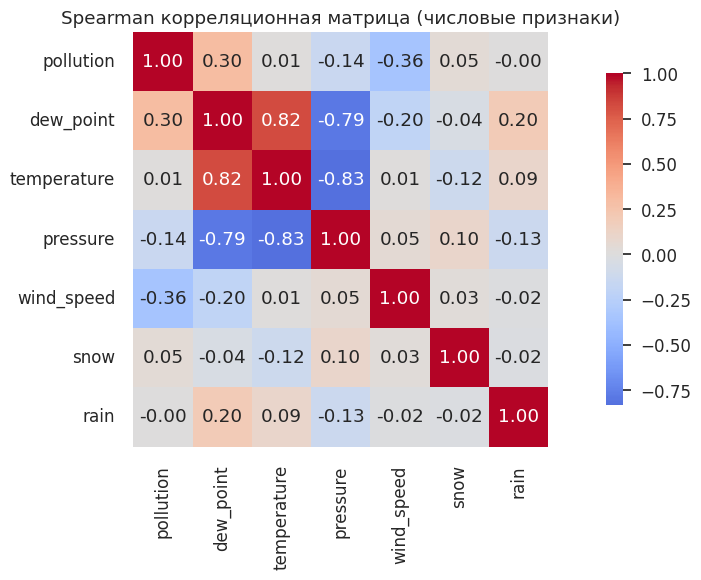

In [90]:
# Spearman correlation
corr_s = df[numeric_cols].corr(method="spearman")

print("Spearman: корреляции с PM2.5 (pollution)")
print(corr_s["pollution"].sort_values(ascending=False))

plt.figure(figsize=(12, 6))
sns.heatmap(
    corr_s,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Spearman корреляционная матрица (числовые признаки)")
plt.tight_layout()
plt.show()

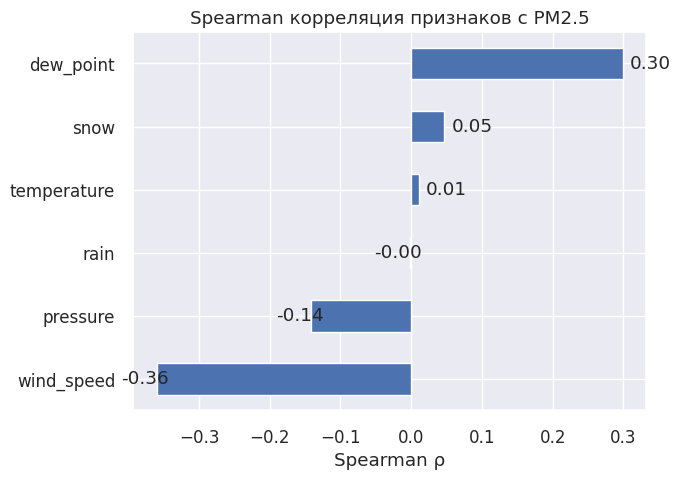

In [91]:
corr_pm = corr_s["pollution"].drop("pollution").sort_values()

plt.figure(figsize=(7, 5))
ax = corr_pm.plot(kind="barh")

for i, v in enumerate(corr_pm.values):
    ax.text(
        v + 0.01 if v >= 0 else v - 0.05,
        i,
        f"{v:.2f}",
        va="center"
    )

plt.title("Spearman корреляция признаков с PM2.5")
plt.xlabel("Spearman ρ")
plt.tight_layout()
plt.show()

ADF test for pm2.5
ADF statistic: -21.3388
p-value: 0.0000


<Figure size 1000x400 with 0 Axes>

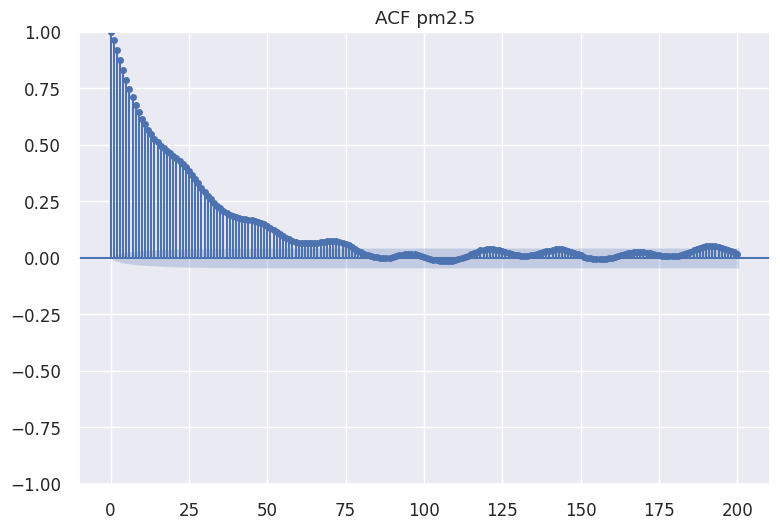

In [92]:
# Автокорреляция pm2.5 (для выбора длины окна RNN)
pm_filled = pm.interpolate(limit_direction="both")
adf_res = adfuller(pm_filled.dropna())
print("ADF test for pm2.5")
print(f"ADF statistic: {adf_res[0]:.4f}")
print(f"p-value: {adf_res[1]:.4f}")

# Автокорреляция
plt.figure(figsize=(10, 4))
plot_acf(pm_filled.dropna(), lags=200)
plt.title("ACF pm2.5")
plt.tight_layout()
plt.show()

## ACF (автокорреляция) показывает,насколько текущее значение PM2.5 связано со значениями k часов назад.
### На этом грфике видно, что значения PM2.5 зависят от предыдущих часов, особенно в пределах последних 24–48 часов. Это означает, что загрязнение воздуха изменяется не резко, а постепенно и имеет суточную закономерность. После 60–70 часов влияние прошлых значений становится слабым, поэтому для RNN достаточно будет использовать окно длиной 24–48 часов.

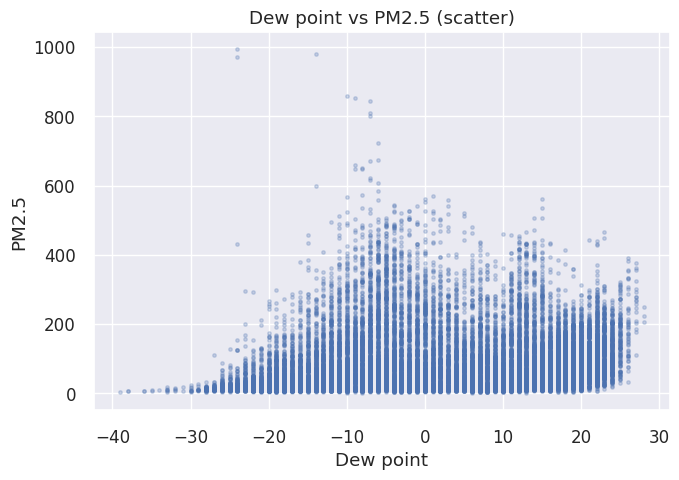

In [93]:
d = df[["dew_point", "pollution"]]
sample = d.sample(min(len(d), 20000), random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(sample["dew_point"], sample["pollution"], s=6, alpha=0.25)
plt.xlabel("Dew point")
plt.ylabel("PM2.5")
plt.title("Dew point vs PM2.5 (scatter)")
plt.tight_layout()
plt.show()

Доля часов без снега (snow > 0) 0.8401826484018264 %
Доля часов с дождём (rain > 0) 4.127853881278539 %


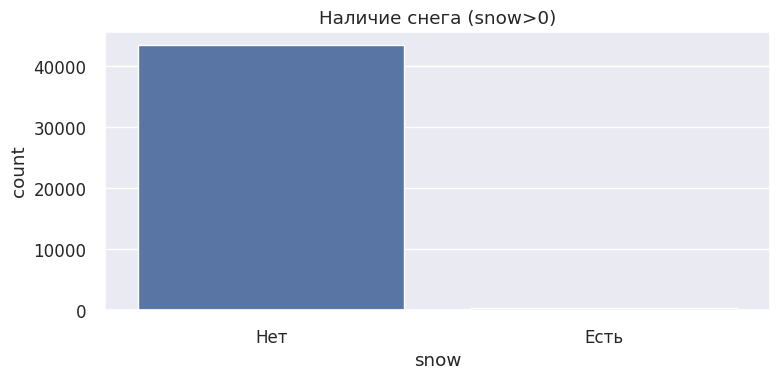

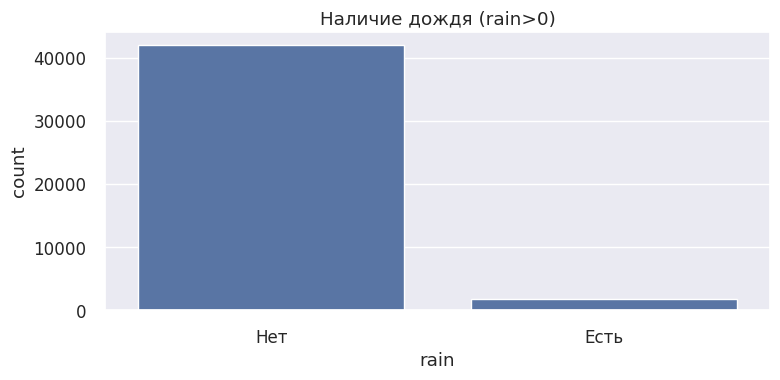

In [94]:
if "snow" in df.columns and "rain" in df.columns:
    print("Доля часов без снега (snow > 0)",
          (df["snow"] > 0).mean() * 100, "%")
    print("Доля часов с дождём (rain > 0)",
          (df["rain"] > 0).mean() * 100, "%")

    plt.figure(figsize=(8, 4))
    sns.countplot(x=(df["snow"] > 0).astype(int))
    plt.title("Наличие снега (snow>0)")
    plt.xticks([0, 1], ["Нет", "Есть"])
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.countplot(x=(df["rain"] > 0).astype(int))
    plt.title("Наличие дождя (rain>0)")
    plt.xticks([0, 1], ["Нет", "Есть"])
    plt.tight_layout()
    plt.show()

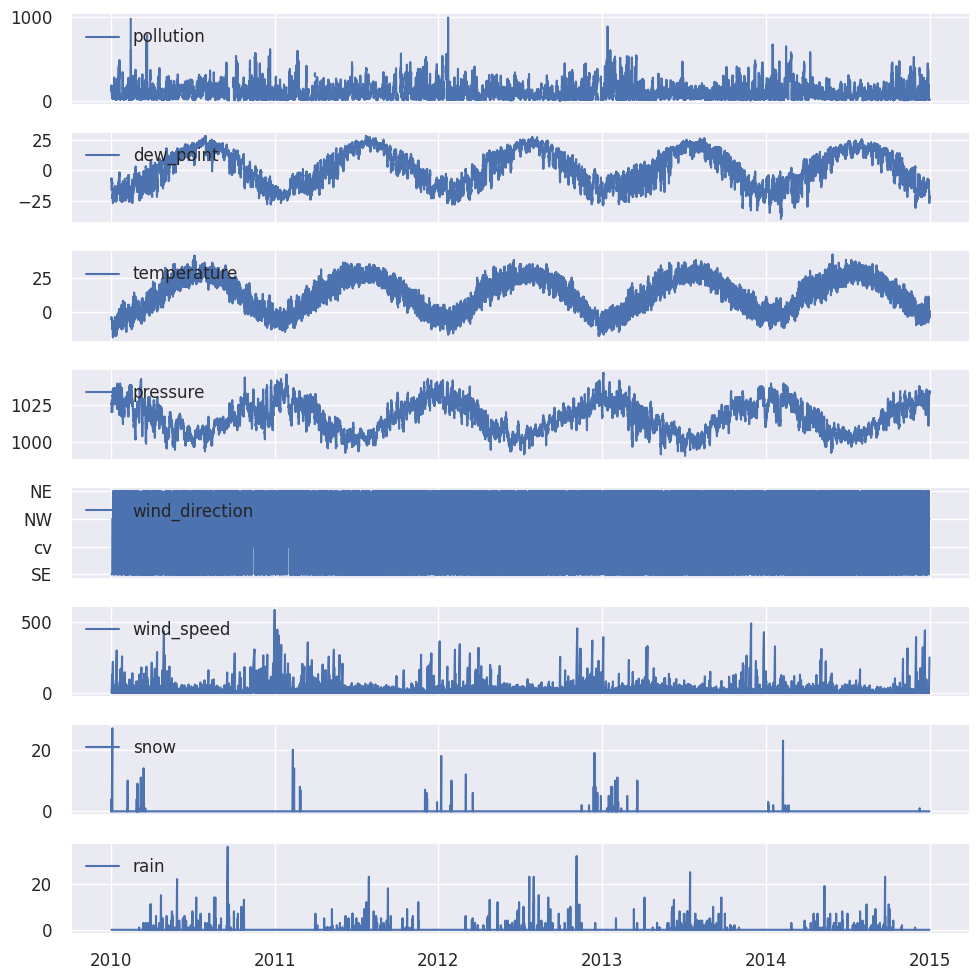

In [95]:
cols = ["pollution","dew_point","temperature","pressure",
        "wind_direction","wind_speed","snow","rain"]

fig, axes = plt.subplots(nrows=len(cols), ncols=1,
                         figsize=(10, 10),
                         sharex=True)

for i, col in enumerate(cols):
    axes[i].plot(df[col], label=col)
    axes[i].legend(loc="upper left")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [96]:
def iqr_outlier_report(df, cols, k=1.5):
    rows = []
    for c in cols:
        x = df[c].dropna()
        if x.empty:
            continue
        q1, q3 = x.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - k*iqr, q3 + k*iqr
        n_out = ((x < low) | (x > high)).sum()
        rows.append({
            "feature": c,
            "n": x.shape[0],
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower": low,
            "upper": high,
            "outliers_n": int(n_out),
            "outliers_%": float(n_out / x.shape[0] * 100)
        })
    return pd.DataFrame(rows).sort_values("outliers_%", ascending=False)

numeric_cols = df.select_dtypes(include=[np.number]).columns
out_iqr = iqr_outlier_report(df, numeric_cols, k=1.5)

display(out_iqr.head(15))

,feature,n,q1,q3,iqr,lower,upper,outliers_n,outliers_%
4,wind_speed,43800,1.79,21.91,20.12,-28.39,52.09,5101,11.646119
0,pollution,41757,29.00,137.00,108.00,-133.00,299.00,1773,4.245995
6,rain,43800,0.00,0.00,0.00,0.00,0.00,1808,4.127854
5,snow,43800,0.00,0.00,0.00,0.00,0.00,368,0.840183
1,dew_point,43800,-10.00,15.00,25.00,-47.50,52.50,0,0.000000
2,temperature,43800,2.00,23.00,21.00,-29.50,54.50,0,0.000000
3,pressure,43800,1008.00,1025.00,17.00,982.50,1050.50,0,0.000000


**ВЫВОДЫ по графикам**

1. pollution (PM2.5)

сильная вариативность, есть выбросы , нет монотонного тренда (PM не растёт и не падает постоянно), но есть крупные циклы зимы–лета.

2. dew_point и temperature

выраженная сезонность,повторяющиеся волны каждый год.

3. pressure

тоже годовая сезонность, помогает понять погоду.

4. wind_direction (cbwd) категориальный признак

6. wind_speed
видны периоды спокойной атмосферы и сильных ветров, резкие скачки важны, так какветер снижает pollution.

6. snow и rain редкие события, слабые, но потенциально полезные

## Preprocessing


In [97]:
df = df.sort_index()
assert isinstance(df.index, pd.DatetimeIndex) 

In [98]:
# Time-split

train_end = pd.Timestamp("2013-12-31 23:00:00")
val_end = pd.Timestamp("2014-09-30 23:00:00")

df_train = df.loc[df.index <= train_end].copy()
df_val = df.loc[(df.index > train_end) & (df.index <= val_end)].copy()
df_test = df.loc[df.index > val_end].copy()


# кодируем время так, чтобы модель понимала цикличность суток и сезонов, а не воспринимала часы и месяцы как линейные числа.
def add_time_features(d):
    d["hour_sin"] = np.sin(2*np.pi * d.index.hour / 24)
    d["hour_cos"] = np.cos(2*np.pi * d.index.hour / 24)
    d["month_sin"] = np.sin(2*np.pi * d.index.month / 12)
    d["month_cos"] = np.cos(2*np.pi * d.index.month / 12)
    return d

df_train = add_time_features(df_train)
df_val = add_time_features(df_val)
df_test = add_time_features(df_test)

In [99]:
# Ветер (wind_id) 

def make_wind_id(train, val, test):
    train["wind_id"] = train["wind_direction"].map(wind_map).astype("int32")
    val["wind_id"] = val["wind_direction"].map(wind_map).astype("int32")
    test["wind_id"] = test["wind_direction"].map(wind_map).astype("int32")
    return train, val, test

wind_map = {"NE": 0, "SE": 1, "NW": 2, "cv": 3}
UNK_WIND = 4

df_train, df_val, df_test = make_wind_id(df_train, df_val, df_test)

In [100]:
def impute_pollution(train_s, val_s, test_s):
    
    train_f = train_s.interpolate("time").ffill().bfill()
    last_train = train_f.iloc[-1]
    val_f = val_s.fillna(last_train).interpolate("time").ffill().bfill()
    
    last_val = val_f.iloc[-1]
    test_f = test_s.fillna(last_val).interpolate("time").ffill().bfill()

    return train_f, val_f, test_f



df_train["pollution"], df_val["pollution"], df_test["pollution"] = \
    impute_pollution(
        df_train["pollution"],
        df_val["pollution"],
        df_test["pollution"]
    )

In [101]:
# LOG1 для pollution
def safe_log1p(x: pd.Series) -> pd.Series:
    return np.log1p(np.clip(x.astype("float32"), 0, None))
df_train["pollution"] = safe_log1p(df_train["pollution"])
df_val["pollution"] = safe_log1p(df_val["pollution"])
df_test["pollution"] = safe_log1p(df_test["pollution"])

# matrices
num_features = [
    "pollution",
    "dew_point",
    "temperature",
    "pressure",
    "wind_speed",
    "snow",
    "rain",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos"
]
X_num_train = df_train[num_features].to_numpy(dtype="float32")
X_num_val = df_val[num_features].to_numpy(dtype="float32")
X_num_test = df_test[num_features].to_numpy(dtype="float32")

X_wind_train = df_train["wind_id"].to_numpy(dtype="int32")
X_wind_val = df_val["wind_id"].to_numpy(dtype="int32")
X_wind_test = df_test["wind_id"].to_numpy(dtype="int32")

In [102]:
# Скейлинг 
scaler = RobustScaler()
scaler.fit(X_num_train)

X_num_train_s = scaler.transform(X_num_train).astype("float32")
X_num_val_s = scaler.transform(X_num_val).astype("float32")
X_num_test_s = scaler.transform(X_num_test).astype("float32")

In [103]:
# Окна
WINDOW = 48
HORIZON = 1
TARGET_COL = 0

def make_windows_multimodal(Xnum, Xwind, window, horizon=1, target_col=0):
    Xn_list, Xw_list, y_list = [], [], []
    T = len(Xnum)
    for i in range(T - window - horizon + 1):
        Xn_list.append(Xnum[i:i+window, :])
        Xw_list.append(Xwind[i:i+window])
        y_list.append(Xnum[i+window:i+window+horizon, target_col])
    return np.array(Xn_list), np.array(Xw_list), np.array(y_list)

Xn_train, Xw_train, y_train = make_windows_multimodal(X_num_train_s, X_wind_train, WINDOW, HORIZON, TARGET_COL)
Xn_val, Xw_val, y_val = make_windows_multimodal(X_num_val_s, X_wind_val, WINDOW, HORIZON, TARGET_COL)
Xn_test, Xw_test, y_test  = make_windows_multimodal(X_num_test_s,  X_wind_test, WINDOW, HORIZON, TARGET_COL)

Xw_train = Xw_train.astype("int32")
Xw_val = Xw_val.astype("int32")
Xw_test = Xw_test.astype("int32")

print("Xn_train:", Xn_train.shape, "Xw_train:", Xw_train.shape, "y_train:", y_train.shape)
n_num_features = Xn_train.shape[2]  
N_WIND_CATS = 5

Xn_train: (34992, 48, 11) Xw_train: (34992, 48) y_train: (34992, 1)


## Baseline

In [104]:
numeric_input = Input(shape=(WINDOW, n_num_features),name="numeric_seq")
wind_input = Input(shape=(WINDOW,),dtype="int32",name="wind_seq")
wind_embed = layers.Embedding(
    input_dim=4,     # NE, SE, NW, cv
    output_dim=2,   
    name="wind_embedding"
)(wind_input)      

# Склеиваем числовые фичи и эмбеддинг по последней оси
x = layers.Concatenate(axis=-1, name="concat_num_wind")([numeric_input, wind_embed]) 
x = layers.LSTM(64,return_sequences=False,name="lstm_1")(x)
x = layers.Dropout(0.2, name="dropout_1")(x)
x = layers.Dense(32, activation="relu", name="dense_1")(x)
output = layers.Dense(1, name="pollution_forecast")(x)
model = Model(
    inputs=[numeric_input, wind_input],
    outputs=output,
    name="baseline_lstm_embedding"
)

model.summary()

Model: "baseline_lstm_embedding"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wind_seq            │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_seq         │ (None, 48, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wind_embedding      │ (None, 48, 2)     │          8 │ wind_seq[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_num_wind     │ (None, 48, 13)    │          0 │ numeric_seq[0][0… │
│ (Concatenate)       │                   │            │ wind_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     19,968 │ concat_num_wind[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pollution_forecast  │ (None, 1)         │         33 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,089 (86.29 KB)

 Trainable params: 22,089 (86.29 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
model.compile(optimizer="adam", loss="mae", metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    x=[Xn_train, Xw_train],
    y=y_train,
    validation_data=([Xn_val, Xw_val], y_val),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - loss: 0.1755 - mae: 0.1755 - rmse: 0.2557 - val_loss: 0.1225 - val_mae: 0.1225 - val_rmse: 0.1912 - learning_rate: 0.0010
Epoch 2/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.1281 - mae: 0.1281 - rmse: 0.1886 - val_loss: 0.1150 - val_mae: 0.1150 - val_rmse: 0.1832 - learning_rate: 0.0010
Epoch 3/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.1212 - mae: 0.1212 - rmse: 0.1810 - val_loss: 0.1156 - val_mae: 0.1156 - val_rmse: 0.1868 - learning_rate: 0.0010
Epoch 4/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.1185 - mae: 0.1185 - rmse: 0.1781 - val_loss: 0.1105 - val_mae: 0.1105 - val_rmse: 0.1802 - learning_rate: 0.0010
Epoch 5/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - loss: 0.1171 - mae: 0.1171 - rmse: 0.1773 - val_loss: 0.1110 - val_mae: 0.1110 - val_rmse: 0.1811 - learning_rate: 0.0010
Epoch 6/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.1160 - mae: 0.1160 - rmse: 0.1760 - val_loss: 0.

<Figure size 800x400 with 0 Axes>

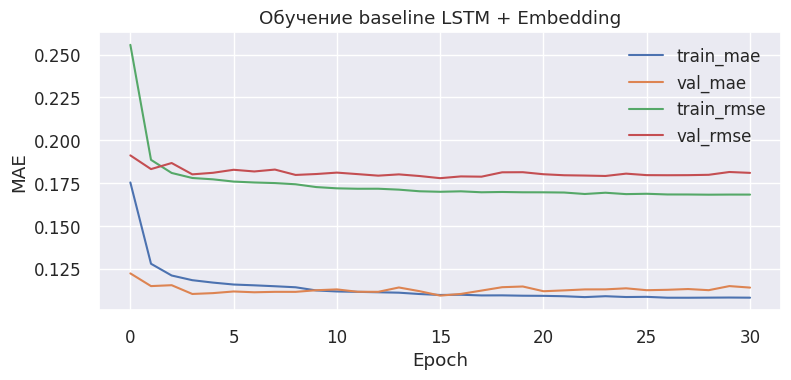

In [106]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="train_mae")
plt.plot(history.history["val_loss"], label="val_mae")
plt.plot(history.history['rmse'], label='train_rmse')
plt.plot(history.history['val_rmse'], label='val_rmse')
plt.xlabel("Epoch")
plt.xlabel("Epoch")
plt.ylabel("Metrics")
plt.title("Обучение baseline LSTM + Embedding")
plt.legend()
plt.tight_layout()
plt.show()

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.1064 - mae: 0.1064 - rmse: 0.1653
Train MAE:0.106
Train RMSE:0.165
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


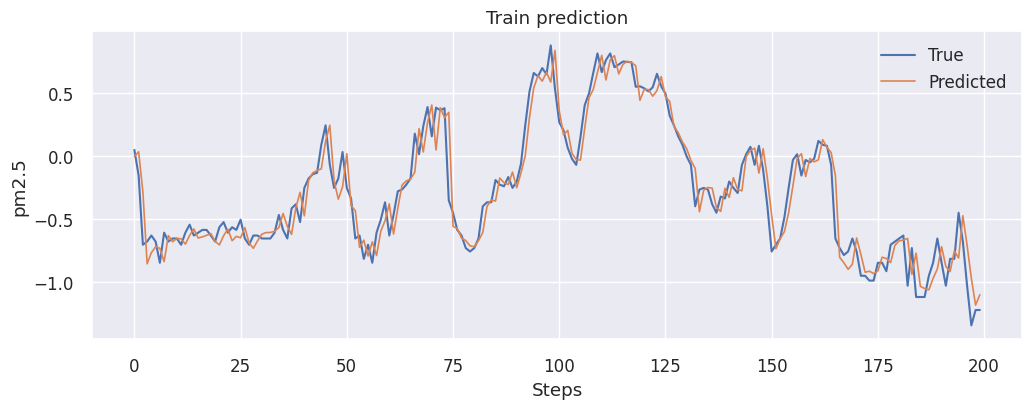

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1192 - mae: 0.1192 - rmse: 0.1875
Test MAE:0.119
Test RMSE:0.187
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


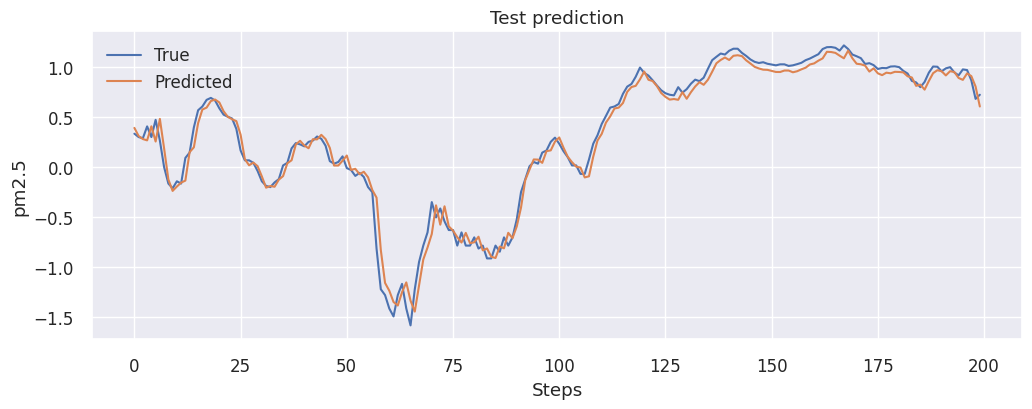

In [111]:
# TRAIN
train_loss, train_mae, train_rmse = model.evaluate([Xn_train, Xw_train], y_train, verbose=1)
print(f"Train MAE:{train_mae:.3f}")
print(f"Train RMSE:{train_rmse:.3f}")

y_pred_train = model.predict([Xn_train, Xw_train]).squeeze()
y_true_train = y_train.squeeze()

N_SHOW = 200
plt.figure(figsize=(12,4))
plt.plot(y_true_train[:N_SHOW], label="True", linewidth=1.5)
plt.plot(y_pred_train[:N_SHOW], label="Predicted", linewidth=1.2)
plt.title("Train prediction")
plt.xlabel("Steps")
plt.ylabel("pm2.5")
plt.legend()
plt.show()


# TEST
test_loss, test_mae, test_rmse = model.evaluate([Xn_test, Xw_test], y_test,verbose=1)
print(f"Test MAE:{test_mae:.3f}")
print(f"Test RMSE:{test_rmse:.3f}")

y_pred_test = model.predict([Xn_test, Xw_test]).squeeze()
y_true_test = y_test.squeeze()

plt.figure(figsize=(12,4))
plt.plot(y_true_test[:N_SHOW], label="True")
plt.plot(y_pred_test[:N_SHOW], label="Predicted")
plt.title("Test prediction")
plt.xlabel("Steps")
plt.ylabel("pm2.5")
plt.legend()
plt.show()

## Visualisation

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test MAE: 13.53 mg/m3
Test RMSE: 25.16 mg/m3


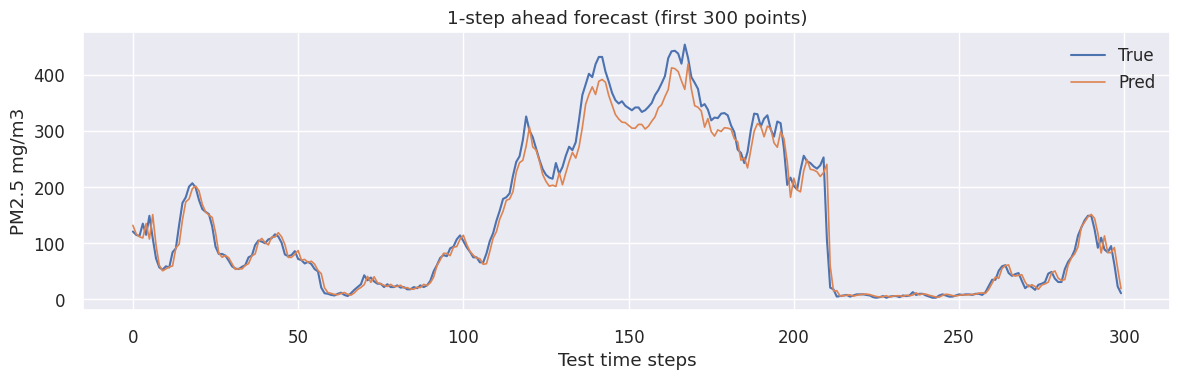

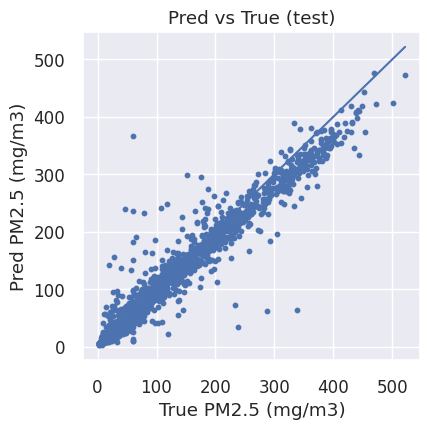

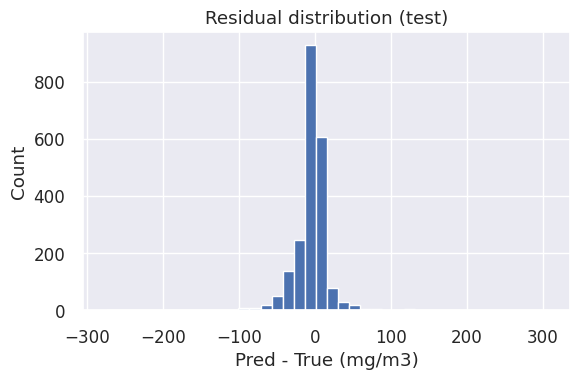

In [112]:
# Inverse scaling
TARGET_COL = 0 

y_pred_s = model.predict([Xn_test, Xw_test])  
y_true_s = y_test 

poll_center = scaler.center_[TARGET_COL]
poll_scale = scaler.scale_[TARGET_COL]
y_pred = (y_pred_s.squeeze() * poll_scale) + poll_center   
y_true = (y_true_s.squeeze() * poll_scale) + poll_center 

# Inverse log1p
y_pred = np.expm1(y_pred)
y_true = np.expm1(y_true)

# Метрики
mae = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true)**2))
print(f"Test MAE: {mae:.2f} mg/m3")  
print(f"Test RMSE: {rmse:.2f} mg/m3")

# True vs Pred по времени 
N_SHOW = 300
plt.figure(figsize=(12,4))
plt.plot(y_true[:N_SHOW], label="True", linewidth=1.5)
plt.plot(y_pred[:N_SHOW], label="Pred", linewidth=1.2)
plt.title(f"1-step ahead forecast (first {N_SHOW} points)")
plt.xlabel("Test time steps")
plt.ylabel("PM2.5 mg/m3")
plt.legend()
plt.tight_layout()
plt.show()

# Scatter( Pred vs True)
plt.figure(figsize=(4.5,4.5))
plt.scatter(y_true, y_pred, s=10)
mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx])  
plt.title("Pred vs True (test)")
plt.xlabel("True PM2.5 (mg/m3)")
plt.ylabel("Pred PM2.5 (mg/m3)")
plt.tight_layout()
plt.show()

#Гистограмма ошибок
res = y_pred - y_true
plt.figure(figsize=(6,4))
plt.hist(res, bins=40)
plt.title("Residual distribution (test)")
plt.xlabel("Pred - True (mg/m3)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##  RESIDUALS
### Ошибки модели в основном малы и колеблются вокруг нуля, однако в периоды резких изменений загрязнения наблюдаются отклонения, что указывает на сложность прогнозирования экстремальных событий.

## Multi-step 24 hours

In [113]:
WINDOW = 48     
HORIZON = 24       
TARGET_COL = 0     

def make_windows_multimodal(Xnum, Xwind, window, horizon=24, target_col=0):
    Xn_list, Xw_list, y_list = [], [], []
    T = len(Xnum)
    for i in range(T - window - horizon + 1):
        Xn_list.append(Xnum[i:i+window, :])                 
        Xw_list.append(Xwind[i:i+window])                        
        y_list.append(Xnum[i+window:i+window+horizon, target_col])  
    return np.array(Xn_list), np.array(Xw_list), np.array(y_list)

Xn_train, Xw_train, y_train = make_windows_multimodal(X_num_train_s, X_wind_train, WINDOW, HORIZON, TARGET_COL)
Xn_val, Xw_val, y_val = make_windows_multimodal(X_num_val_s, X_wind_val, WINDOW, HORIZON, TARGET_COL)
Xn_test, Xw_test, y_test = make_windows_multimodal(X_num_test_s,  X_wind_test, WINDOW, HORIZON, TARGET_COL)

Xw_train = Xw_train.astype("int32")
Xw_val = Xw_val.astype("int32")
Xw_test = Xw_test.astype("int32")

print("Shapes:")
print("Xn_train:", Xn_train.shape, "Xw_train:", Xw_train.shape, "y_train:", y_train.shape)

Shapes:
Xn_train: (34969, 48, 11) Xw_train: (34969, 48) y_train: (34969, 24)


## 1 layer LSTM

In [114]:
window = Xn_train.shape[1]
n_num_features = Xn_train.shape[2]

numeric_input = Input(shape=(window, n_num_features), name="numeric_seq")
wind_input = Input(shape=(window,), dtype="int32", name="wind_seq")

N_WIND_CATS = 5
wind_embed = layers.Embedding(input_dim=N_WIND_CATS, output_dim=2, name="wind_embedding")(wind_input)

x = layers.Concatenate(axis=-1, name="concat_num_wind")([numeric_input, wind_embed])
x = layers.LSTM(64, return_sequences=False, name="lstm_1")(x)
x = layers.Dropout(0.2, name="dropout_1")(x)
x = layers.Dense(32, activation="relu", name="dense_1")(x)
output = layers.Dense(HORIZON, name="pollution_forecast_24h")(x)
model = Model(inputs=[numeric_input, wind_input], outputs=output, name="lstm_embedding_24h")
model.summary()

model.compile(optimizer="adam", loss="mae", metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")])

Model: "lstm_embedding_24h"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wind_seq            │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_seq         │ (None, 48, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wind_embedding      │ (None, 48, 2)     │         10 │ wind_seq[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_num_wind     │ (None, 48, 13)    │          0 │ numeric_seq[0][0… │
│ (Concatenate)       │                   │            │ wind_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     19,968 │ concat_num_wind[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pollution_forecast… │ (None, 24)        │        792 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,850 (89.26 KB)

 Trainable params: 22,850 (89.26 KB)

 Non-trainable params: 0 (0.00 B)

In [115]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-5, verbose=1)

history = model.fit(
    x=[Xn_train, Xw_train],
    y=y_train,
    validation_data=([Xn_val, Xw_val], y_val),
    epochs=20,
    batch_size=48,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - loss: 0.3861 - mae: 0.3861 - rmse: 0.5270 - val_loss: 0.3571 - val_mae: 0.3571 - val_rmse: 0.4974 - learning_rate: 0.0010
Epoch 2/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.3531 - mae: 0.3531 - rmse: 0.4955 - val_loss: 0.3533 - val_mae: 0.3533 - val_rmse: 0.4963 - learning_rate: 0.0010
Epoch 3/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.3413 - mae: 0.3413 - rmse: 0.4813 - val_loss: 0.3607 - val_mae: 0.3607 - val_rmse: 0.5124 - learning_rate: 0.0010
Epoch 4/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 0.3302 - mae: 0.3302 - rmse: 0.4660 - val_loss: 0.3617 - val_mae: 0.3617 - val_rmse: 0.5179 - learning_rate: 0.0010
Epoch 5/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - loss: 0.3197 - mae: 0.3197 - rmse: 0.4521 - val_loss: 0.3624 - val_mae: 0.3624 - val_rmse: 0.5118 - learning_rate: 0.0010
Epoch 6/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 0.3056 - mae: 0.3056 - rmse: 0.4321 - val_loss: 

In [116]:
TARGET_COL = 0
poll_center = scaler.center_[TARGET_COL]
poll_scale = scaler.scale_[TARGET_COL]

y_pred_s = model.predict([Xn_test, Xw_test])    
y_true_s = y_test                            

y_pred = y_pred_s * poll_scale + poll_center
y_true = y_true_s * poll_scale + poll_center

# Inverse log1p
y_pred = np.expm1(y_pred)
y_true = np.expm1(y_true)

mae_24h  = np.mean(np.abs(y_pred - y_true))
rmse_24h = np.sqrt(np.mean((y_pred - y_true)**2))

print(f"Test MAE (avg over 24h): {mae_24h:.2f}")
print(f"Test RMSE (avg over 24h): {rmse_24h:.2f}")

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Test MAE (avg over 24h): 55.43
Test RMSE (avg over 24h): 91.16


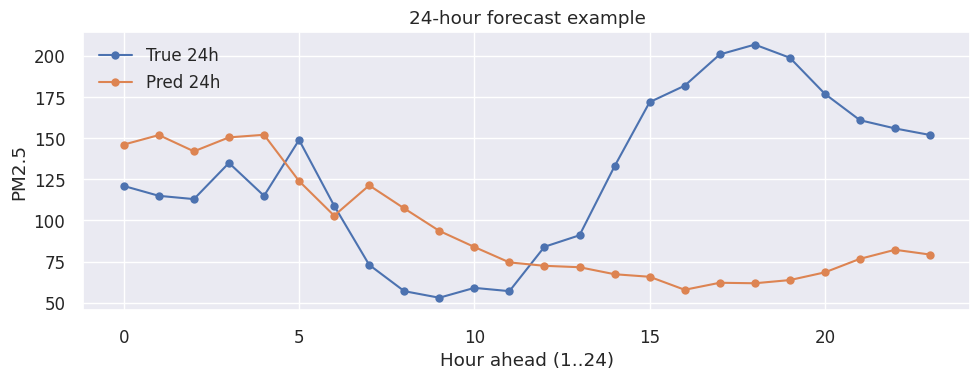

In [117]:
k = 0
plt.figure(figsize=(10,4))
plt.plot(y_true[k], label="True 24h", marker="o")
plt.plot(y_pred[k], label="Pred 24h", marker="o")
plt.xlabel("Hour ahead (1..24)")
plt.ylabel("PM2.5")
plt.title("24-hour forecast example")
plt.legend()
plt.tight_layout()
plt.show()

## 2 layers LSTM

In [118]:
window = Xn_train.shape[1]
n_num_features = Xn_train.shape[2]

numeric_input = Input(shape=(window, n_num_features), name="numeric_seq")
wind_input = Input(shape=(window,), dtype="int32", name="wind_seq")

N_WIND_CATS = 5
wind_embed = layers.Embedding(input_dim=N_WIND_CATS, output_dim=2, name="wind_embedding")(wind_input)

x = layers.Concatenate(axis=-1, name="concat_num_wind")([numeric_input, wind_embed])
x = layers.LSTM(64, return_sequences=True, name="lstm_1")(x)
x = layers.Dropout(0.2, name="dropout_1")(x)
x = layers.LSTM(32, return_sequences=False, name="lstm_2")(x)
x = layers.Dropout(0.2, name="dropout_2")(x)
x = layers.Dense(32, activation="relu", name="dense_1")(x)

# на 24 часа
output = layers.Dense(HORIZON, name="pollution_forecast_24h")(x)
model = Model(inputs=[numeric_input, wind_input], outputs=output, name="lstm2_embedding_48to24")
model.summary()

Model: "lstm2_embedding_48to24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wind_seq            │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_seq         │ (None, 48, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wind_embedding      │ (None, 48, 2)     │         10 │ wind_seq[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_num_wind     │ (None, 48, 13)    │          0 │ numeric_seq[0][0… │
│ (Concatenate)       │                   │            │ wind_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 48, 64)    │     19,968 │ concat_num_wind[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │     12,416 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pollution_forecast… │ (None, 24)        │        792 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,242 (133.76 KB)

 Trainable params: 34,242 (133.76 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
model.compile(optimizer="adam", loss="mae", metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")])

early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1)

history = model.fit(
    x=[Xn_train, Xw_train],
    y=y_train,
    validation_data=([Xn_val, Xw_val], y_val),
    epochs=13,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/13
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.3977 - mae: 0.3977 - rmse: 0.5365 - val_loss: 0.3587 - val_mae: 0.3587 - val_rmse: 0.4999 - learning_rate: 0.0010
Epoch 2/13
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 0.3588 - mae: 0.3588 - rmse: 0.4980 - val_loss: 0.3570 - val_mae: 0.3570 - val_rmse: 0.4982 - learning_rate: 0.0010
Epoch 3/13
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - loss: 0.3425 - mae: 0.3425 - rmse: 0.4790 - val_loss: 0.3626 - val_mae: 0.3626 - val_rmse: 0.5098 - learning_rate: 0.0010
Epoch 4/13
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 0.3261 - mae: 0.3261 - rmse: 0.4567 - val_loss: 0.3768 - val_mae: 0.3768 - val_rmse: 0.5325 - learning_rate: 0.0010
Epoch 5/13
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.3120 - mae: 0.3120 - rmse: 0.4385 - val_loss: 0.3782 - val_mae: 0.3782 - val_rmse: 0.5374 - learning_rate: 0.0010
Epoch 6/13
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.2923 - mae: 0.2923 - rmse: 0.4108 - val_loss: 

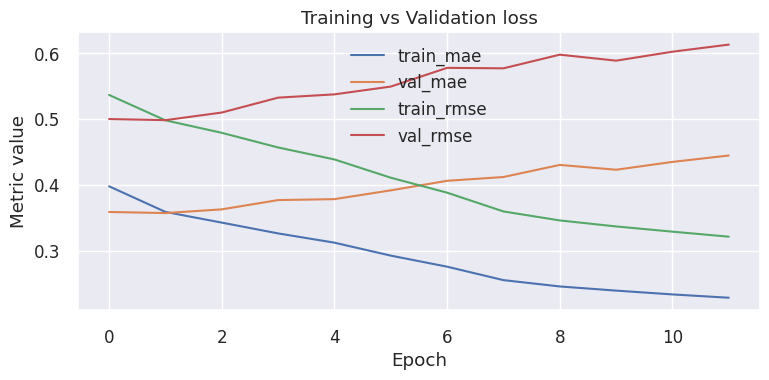

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


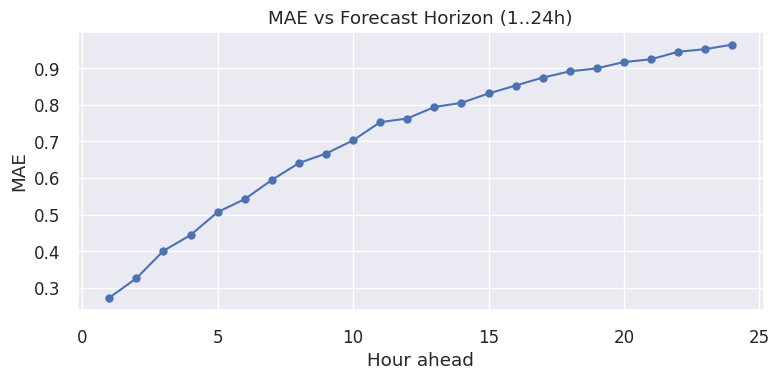

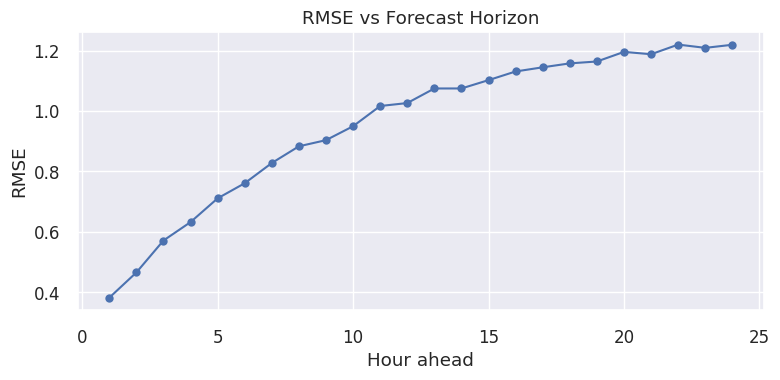

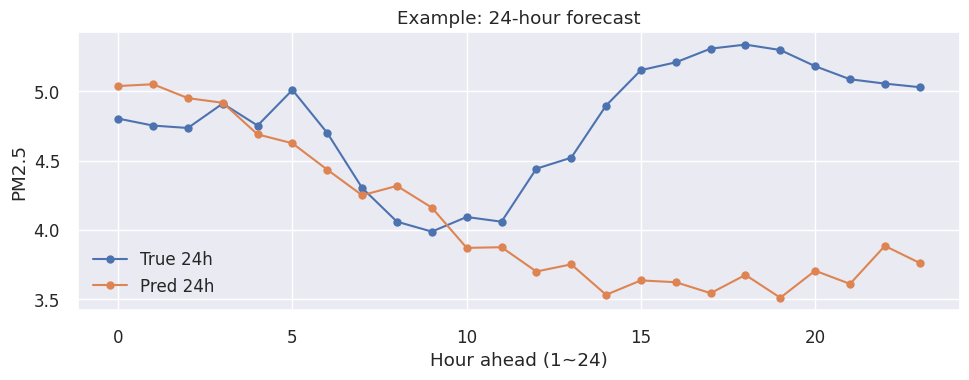

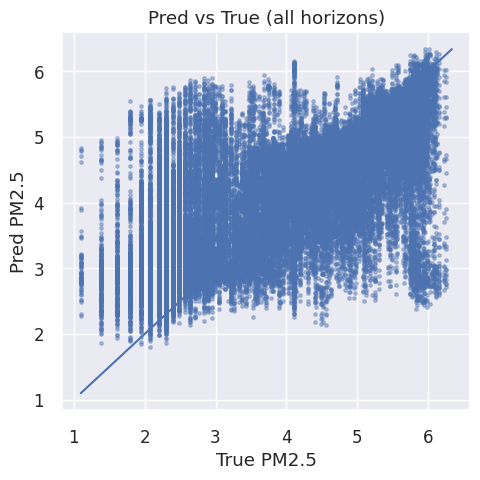

MAE:0.720
RMSE:0.990


In [120]:
# Visualisation

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="train_mae")
plt.plot(history.history["val_loss"], label="val_mae")
plt.plot(history.history['rmse'], label='train_rmse')
plt.plot(history.history['val_rmse'], label='val_rmse')
plt.xlabel("Epoch")
plt.ylabel("Metric value")  
plt.title("Training vs Validation loss")
plt.legend()
plt.tight_layout()
plt.show()

y_pred_s = model.predict([Xn_test, Xw_test])  
y_true_s = y_test                            

# Inverse Scaling
poll_center = scaler.center_[TARGET_COL]
poll_scale = scaler.scale_[TARGET_COL]

y_pred = y_pred_s * poll_scale + poll_center
y_true = y_true_s * poll_scale + poll_center

# Mae by Horizon
mae_by_h = np.mean(np.abs(y_pred - y_true), axis=0) 

plt.figure(figsize=(8,4))
plt.plot(range(1, HORIZON+1), mae_by_h, marker="o")
plt.xlabel("Hour ahead")
plt.ylabel("MAE")
plt.title("MAE vs Forecast Horizon (1..24h)")
plt.grid(True)
plt.tight_layout()
plt.show()

# RMSE by Horizon
rmse_by_h = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))

plt.figure(figsize=(8,4))

plt.plot(range(1, HORIZON + 1), rmse_by_h, marker="o")

plt.xlabel("Hour ahead")
plt.ylabel("RMSE")
plt.title("RMSE vs Forecast Horizon")

plt.grid(True)
plt.tight_layout()
plt.show()

#Example Forecast
k = 0  
plt.figure(figsize=(10,4))
plt.plot(y_true[k], label="True 24h", marker="o")
plt.plot(y_pred[k], label="Pred 24h", marker="o")
plt.xlabel("Hour ahead (1~24)")
plt.ylabel("PM2.5")
plt.title("Example: 24-hour forecast")
plt.legend()
plt.tight_layout()
plt.show()


yt = y_true.reshape(-1)
yp = y_pred.reshape(-1)

plt.figure(figsize=(5,5))
plt.scatter(yt, yp, s=6, alpha=0.4)
mn = min(yt.min(), yp.min())
mx = max(yt.max(), yp.max())
plt.plot([mn, mx], [mn, mx]) 
plt.xlabel("True PM2.5")
plt.ylabel("Pred PM2.5")
plt.title("Pred vs True (all horizons)")
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(yt - yp))
rmse = np.sqrt(np.mean((yt - yp) ** 2))

print(f"MAE:{mae:.3f}")
print(f"RMSE:{rmse:.3f}")

## LSTM + LSTM decoder (Seq2Seq)
### Encoder returns sequences (для attention)
### Positional / hour embedding (декодер знает "какой час", помогает модели различать близкий и дальний горизонт прогноза, что важно для ухудшения качества на дальних шагах)
### Teacher forcing (вместо угадывания предыдущего шага декодер получает правильный предыдущий ответ)
### Attention(модель не смотрит на всё прошлое одинаково,а выбирает самые важные часы из истории)

In [121]:
WINDOW  = 48
HORIZON = 24
N_WIND_CATS = 4
WIND_EMB_DIM = 2
HOUR_EMB_DIM = 2

ENC_UNITS = 64
DEC_UNITS = 64

In [122]:
def make_decoder_inputs_from_y(y_seq: np.ndarray) -> np.ndarray:
  
    y_in = np.zeros((y_seq.shape[0], y_seq.shape[1], 1), dtype=np.float32)
    y_in[:, 1:, 0] = y_seq[:, :-1]
    return y_in
    

class HourEmbedding(layers.Layer):
    def __init__(self, horizon: int, emb_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.horizon = horizon
        self.emb = layers.Embedding(input_dim=horizon, output_dim=emb_dim, name="hour_embedding")

    def call(self, x):
        bsz = tf.shape(x)[0]
        h_idx = tf.range(self.horizon)               
        h_e = self.emb(h_idx)                             
        h_e = tf.expand_dims(h_e, axis=0)                  
        h_e = tf.tile(h_e, [bsz, 1, 1])                    
        return h_e

In [123]:
window = Xn_train.shape[1]
n_num_features = Xn_train.shape[2]

numeric_input = Input(shape=(window, n_num_features), name="numeric_seq")
wind_input = Input(shape=(window,), dtype="int32", name="wind_seq")

# Teacher forcing input 
dec_y_input = Input(shape=(HORIZON, 1), name="decoder_y_in")
wind_embed = layers.Embedding(
    input_dim=N_WIND_CATS,
    output_dim=WIND_EMB_DIM,
    name="wind_embedding"
)(wind_input) 

# Encoder
enc_in = layers.Concatenate(axis=-1, name="enc_concat")([numeric_input, wind_embed])
enc_seq, state_h, state_c = layers.LSTM(
    ENC_UNITS,
    return_sequences=True,
    return_state=True,
    name="encoder_lstm"
)(enc_in) 

# Decoder
hour_emb = HourEmbedding(HORIZON, HOUR_EMB_DIM, name="hour_emb_layer")(dec_y_input)
dec_in = layers.Concatenate(axis=-1, name="dec_concat")([dec_y_input, hour_emb])
dec_seq = layers.LSTM(
    DEC_UNITS,
    return_sequences=True,
    name="decoder_lstm"
)(dec_in, initial_state=[state_h, state_c]) 
dec_seq = layers.Dropout(0.2, name="dec_dropout")(dec_seq)


# Attention
context = layers.Attention(name="attention")([dec_seq, enc_seq])
dec_ctx = layers.Concatenate(axis=-1, name="dec_context_concat")([dec_seq, context])
out_seq = layers.TimeDistributed(layers.Dense(1), name="pm25_each_hour")(dec_ctx)
output= layers.Reshape((HORIZON,), name="pm25_24h")(out_seq)
model_seq2seq_tf_attn = Model(
    inputs=[numeric_input, wind_input, dec_y_input],
    outputs=output,
    name="seq2seq_lstm_tf_hour_attn"
)

model_seq2seq_tf_attn.summary()

Model: "seq2seq_lstm_tf_hour_attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wind_seq            │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_y_in        │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_seq         │ (None, 48, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wind_embedding      │ (None, 48, 2)     │          8 │ wind_seq[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hour_emb_layer      │ (None, 24, 2)     │         48 │ decoder_y_in[0][… │
│ (HourEmbedding)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_concat          │ (None, 48, 13)    │          0 │ numeric_seq[0][0… │
│ (Concatenate)       │                   │            │ wind_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_concat          │ (None, 24, 3)     │          0 │ decoder_y_in[0][… │
│ (Concatenate)       │                   │            │ hour_emb_layer[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 48, 64),  │     19,968 │ enc_concat[0][0]  │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 24, 64)    │     17,408 │ dec_concat[0][0], │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dropout         │ (None, 24, 64)    │          0 │ decoder_lstm[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 24, 64)    │          0 │ dec_dropout[0][0… │
│ (Attention)         │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_context_concat  │ (None, 24, 128)   │          0 │ dec_dropout[0][0… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pm25_each_hour      │ (None, 24, 1)     │        129 │ dec_context_conc… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pm25_24h (Reshape)  │ (None, 24)        │          0 │ pm25_each_hour[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,561 (146.72 KB)

 Trainable params: 37,561 (146.72 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
# Loss (MAE)
model_seq2seq_tf_attn.compile(optimizer="adam", loss="mae", metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")])
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1)

In [125]:
# teacher forcing inputs
dec_in_train = make_decoder_inputs_from_y(y_train)
dec_in_val = make_decoder_inputs_from_y(y_val)
dec_in_test = make_decoder_inputs_from_y(y_test)


# Train
history = model_seq2seq_tf_attn.fit(
    x=[Xn_train, Xw_train, dec_in_train],
    y=y_train,
    validation_data=([Xn_val, Xw_val, dec_in_val], y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - loss: 0.1631 - mae: 0.1631 - rmse: 0.2513 - val_loss: 0.1153 - val_mae: 0.1153 - val_rmse: 0.1890 - learning_rate: 0.0010
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - loss: 0.1186 - mae: 0.1186 - rmse: 0.1825 - val_loss: 0.1136 - val_mae: 0.1136 - val_rmse: 0.1880 - learning_rate: 0.0010
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - loss: 0.1173 - mae: 0.1173 - rmse: 0.1808 - val_loss: 0.1138 - val_mae: 0.1138 - val_rmse: 0.1880 - learning_rate: 0.0010
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - loss: 0.1167 - mae: 0.1167 - rmse: 0.1802 - val_loss: 0.1132 - val_mae: 0.1132 - val_rmse: 0.1874 - learning_rate: 0.0010
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - loss: 0.1162 - mae: 0.1162 - rmse: 0.1795 - val_loss: 0.1128 - val_mae: 0.1128 - val_rmse: 0.1865 - learning_rate: 0.0010
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - loss: 0.1158 - mae: 0.1158 - rmse: 0.1791 - val_loss: 

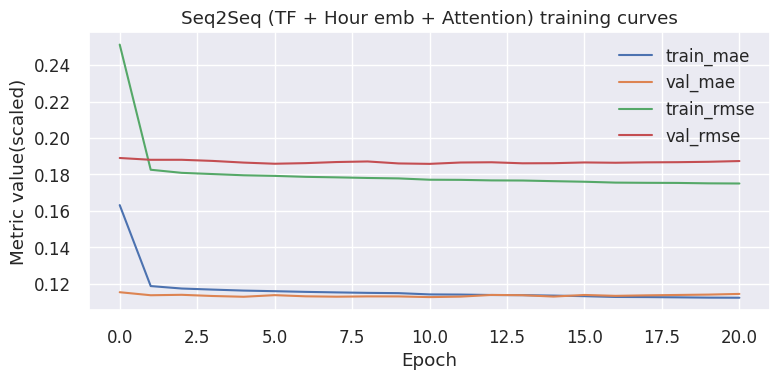

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


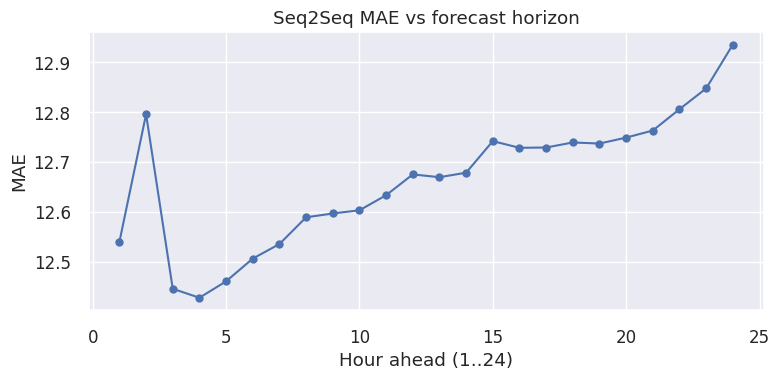

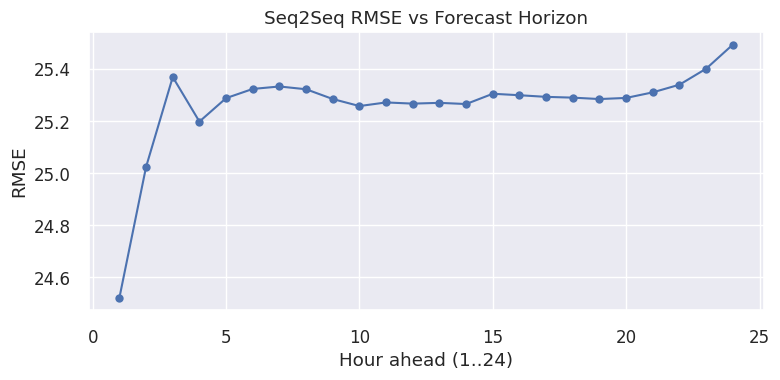

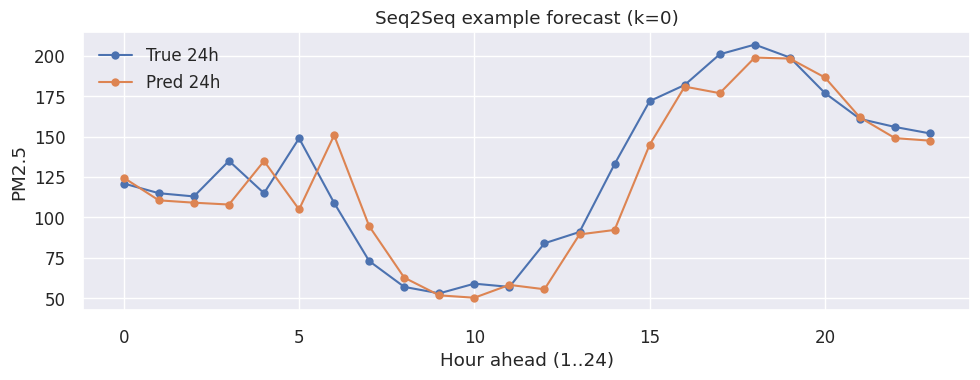

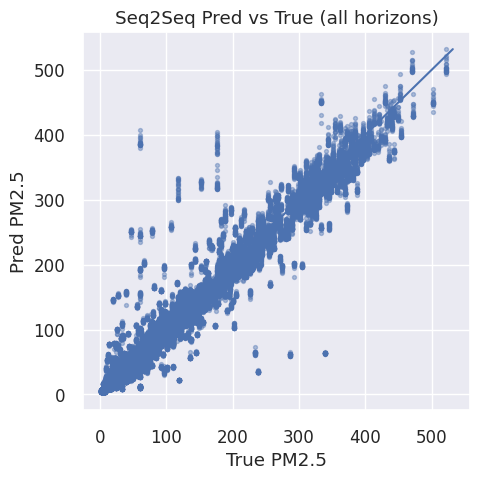

MAE: 12.664
RMSE: 25.263


In [126]:
# Curves

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="train_mae")
plt.plot(history.history["val_loss"], label="val_mae")

plt.plot(history.history["rmse"], label="train_rmse")
plt.plot(history.history["val_rmse"], label="val_rmse")
plt.xlabel("Epoch")
plt.ylabel("Metric value(scaled)")
plt.title("Seq2Seq (TF + Hour emb + Attention) training curves")
plt.legend()
plt.tight_layout()
plt.show()


# Predict (teacher forcing)
y_pred_s = model_seq2seq_tf_attn.predict([Xn_test, Xw_test, dec_in_test])

# Inverse scaling
TARGET_COL = 0
poll_center = scaler.center_[TARGET_COL]
poll_scale = scaler.scale_[TARGET_COL]

y_pred = y_pred_s * poll_scale + poll_center
y_true = y_test * poll_scale + poll_center

# Inverse log1p
y_pred = np.expm1(y_pred)
y_true = np.expm1(y_true)

# MAE by horizon
mae_by_h = np.mean(np.abs(y_pred - y_true), axis=0)

plt.figure(figsize=(8,4))
plt.plot(range(1, HORIZON+1), mae_by_h, marker="o")
plt.xlabel("Hour ahead (1..24)")
plt.ylabel("MAE")
plt.title("Seq2Seq MAE vs forecast horizon")
plt.grid(True)
plt.tight_layout()
plt.show()

# RMSE by horizon
rmse_by_h = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
plt.figure(figsize=(8,4))
plt.plot(range(1, HORIZON + 1), rmse_by_h,marker="o")
plt.xlabel("Hour ahead (1..24)")
plt.ylabel("RMSE")
plt.title("Seq2Seq RMSE vs Forecast Horizon")

plt.grid(True)
plt.tight_layout()
plt.show()

# пример прогноза
k = 0
plt.figure(figsize=(10,4))
plt.plot(y_true[k], label="True 24h", marker="o")
plt.plot(y_pred[k], label="Pred 24h", marker="o")
plt.xlabel("Hour ahead (1..24)")
plt.ylabel("PM2.5")
plt.title(f"Seq2Seq example forecast (k={k})")
plt.legend()
plt.tight_layout()
plt.show()

# Scatter Pred vs True
yt = y_true.reshape(-1)
yp = y_pred.reshape(-1)

plt.figure(figsize=(5,5))
plt.scatter(yt, yp, s=8, alpha=0.4)
mn = min(yt.min(), yp.min())
mx = max(yt.max(), yp.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("True PM2.5")
plt.ylabel("Pred PM2.5")
plt.title("Seq2Seq Pred vs True (all horizons)")
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(yt - yp))
rmse = np.sqrt(np.mean((yt - yp) ** 2))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

In [127]:
yt = y_true.reshape(-1)
yp = y_pred.reshape(-1)

mae_all = mean_absolute_error(yt, yp)
rmse_all = np.sqrt(mean_squared_error(yt, yp))

print(f"Seq2Seq Test MAE: {mae_all:.2f}")
print(f"Seq2Seq Test RMSE: {rmse_all:.2f}")

Seq2Seq Test MAE: 12.66
Seq2Seq Test RMSE: 25.26


### Добавление teacher forcing, временного embedding и attention позволило улучшить устойчивость прогноза и улучшить качество на дальнем горизонте, что подтверждается кривыми обучения, MAE.

## Заключение
В ходе работы мы исследовали временные ряды концентрации PM2.5 и разработали модели глубокого обучения, способные предсказывать качество воздуха на 24 часа вперёд.
Анализ данных показал, что уровень загрязнения меняется в зависимости от времени суток и сезона, а погодные условия оказывают на него значительное влияние. 
Прежде чем приступить к моделированию, мы привели данные в порядок: применили логарифмическое преобразование к целевой переменной, масштабировали признаки, закодировали направление ветра и добавили циклические временные признаки.

Для сравнения мы обучили несколько моделей: от простого базового прогноза до более сложных архитектур, включая однослойную и двухслойную LSTM, а также Seq2Seq с механизмом encoder-decoder. 
LSTM-модели хорошо справились с задачей и уверенно удерживали качество на всём горизонте прогноза, точно улавливая временные зависимости в данных. Архитектура Seq2Seq показала себя на дальних шагах прогнозирования, где простые рекуррентные сети обычно теряют точность.
Качество моделей оценивалось по метрикам MAE и RMSE, а также визуально: мы анализировали, как ошибка накапливается с увеличением горизонта прогнозирования.

В целом проект подтвердил, что рекуррентные нейронные сети являются эффективным инструментом для прогнозирования качества воздуха, а грамотный выбор архитектуры позволяет существенно улучшить результат на длинных горизонтах.